In [1]:
%load_ext autoreload
%autoreload 2

In [75]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

from mad.objs.constants import G0, titan_stage_1, titan_stage_2, EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig, SimulationInterface
from mad.objs.common_schemas import MovableObject, History
from mad.objs.projectiles import ProjectileConfig, Projectile
from mad.logger import SourceLogger

logger = SourceLogger()

In [76]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(-9.819649737724955))

In [77]:
class Payload(MovableObject):
    mass: float # kg
    area: float # m^2
    yield_kt: float # kt


@dataclass
class StageConfig:
    dry_mass: float  # kg
    propellant_mass: float  # kg
    thrust: float # N / s
    Isp: float  # s
    area: float # m^2
    Cd: float
    time_ECO: float # s
    time_sep: float  # s
    payload: Payload | None = None
    name: str = "Stage"

    @property
    def to_dict(self):
        return asdict(self)

In [78]:
class MissileStage:
    def __init__(self, cfg: StageConfig):
        self.config = cfg
        self.dry_mass = cfg.dry_mass
        self.propellant_mass = cfg.propellant_mass

        self.thrust = cfg.thrust
        self.Isp = cfg.Isp

        self.area = cfg.area
        self.Cd = cfg.Cd

        self.exhaust_velocity = cfg.Isp * G0
        self.mass_flow_rate = cfg.thrust / self.exhaust_velocity

        self.active: bool = True
        self.payload = cfg.payload
        self.name = cfg.name
        self.t = 0.0

    @property
    def mass(self)->float:
        payload_mass = self.payload.mass if self.payload else 0.0
        return self.dry_mass + self.propellant_mass + payload_mass

    def thrust_force(self)->float:
        return self.thrust if self.propellant_mass > 0 else 0.0

    def update(self, dt: float)->None:
        self.t += dt
        if not self.active:
            return

        if self.propellant_mass > 0:
            dm = self.mass_flow_rate * dt
            self.propellant_mass = max(0.0, self.propellant_mass - dm)
        else:
            logger["Missile"].info(f"{self.name} ran out of propellant at {self.t:.2f}.")
            self.active = False

In [79]:
@dataclass
class MissileConfig:
    stages: list[MissileStage]
    position: list[float]
    name: str = "MultiStageMissile"
    guidance = None

    @property
    def to_dict(self):
        return asdict(self)

class Missile(SimulationInterface, MovableObject):
    def __init__(self, cfg: MissileConfig):
        super().__init__(position=cfg.position, name = cfg.name)

        self.stages = cfg.stages
        self.guidance = cfg.guidance
        self.t = 0
        self.history = History()

    @property
    def mass(self):
        return sum(stage.mass for stage in self.stages)

    @property
    def area(self):
        return sum(stage.area for stage in self.stages)
    
    @property
    def Cd(self):
        return sum(stage.Cd for stage in self.stages)

    def get_guidance(self)->NDArray:
        return np.ones_like(self.position)

    def thrust_acc(self):

        running_stage = self.stages[0]
        if not running_stage.active:
            return np.zeros_like(self.position)

        direction = self.get_guidance()

        T = running_stage.thrust

        return direction * (T / self.mass)

    def update(self, dt: float) -> None | Projectile:
        self.t += dt
        running_stage = self.stages[0]
        running_stage.update(dt)

        if not running_stage.active:
            stage_cfg = ProjectileConfig(position = self.position.tolist(), 
                                            velocity = self.velocity.tolist(),
                                            mass = running_stage.dry_mass,
                                            name = running_stage.name,
                                            area = running_stage.area,
                                            Cd = running_stage.Cd,
                                            )

            del(self.stages[0])
            logger["Missile"].info(f"{self.name} - {running_stage.name} separated at {self.t:.2f}.")
            if len(self.stages) == 0: 
                self.active = False
                logger["Missile"].info(f"{self.name} inactivated at {self.t:.2f}.")
            return Projectile(stage_cfg)
        else:
            return None

    def accelerations(self, planet: Planet) -> NDArray:
        gravity = planet.gravity(self)
        drag = planet.drag(self)
        thrust = self.thrust_acc()

        return gravity + drag + thrust

    def integrate(self, dt: float, planet: Planet) -> None:
        # Velocity Verlet for solver.
        a0 = self.accelerations(planet)
        self.position += self.velocity * dt + 0.5 * a0 * dt**2
        a1 = self.accelerations(planet)

        self.velocity += 0.5 * (a0 + a1) * dt

        self.history.position.append(self.position.tolist())
        self.history.velocity.append(self.velocity.tolist())

In [80]:
stage1 = MissileStage(StageConfig(**titan_stage_1))
stage2 = MissileStage(StageConfig(**titan_stage_2))


mis_pos = [earth.radius + 1000, 0.0]
titan = Missile(MissileConfig(position = mis_pos, stages = [stage1, stage2], name="Titan I"))

In [81]:
dt = 1
active_objs = [titan]
inactive_objs = []
time_scale = [0.0]
for t in range(1000):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)
        time_scale.append(dt)

    active_objs.extend(new_objects)

21:54:16 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
21:54:16 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
21:54:16 | INFO     | Simulation   | Stage1 added to Simulation.
21:54:16 | INFO     | Missile      | Stage2 ran out of propellant at 232.00.
21:54:16 | INFO     | Missile      | Titan I - Stage2 separated at 342.00.
21:54:16 | INFO     | Missile      | Titan I inactivated at 342.00.
21:54:16 | INFO     | Simulation   | Stage2 added to Simulation.
21:54:16 | INFO     | Projectile   | Stage1 landed on the ground!


In [82]:
stage1.propellant_mass

0.0

In [92]:
def extract_history(objs:list):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)

        posx, posz = pos[:, 0], pos[:, 1]
        velx, velz = vel[:, 0], vel[:, 1]

        altitude = np.sqrt(posx**2 + posz**2) - earth.radius
        velout = np.sqrt(velx**2 + velz**2)

        results[obj.name] = {"altitude": altitude, "velocity":velout, "posx":posx, "posz":posz}

    return results

results = extract_history(active_objs)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

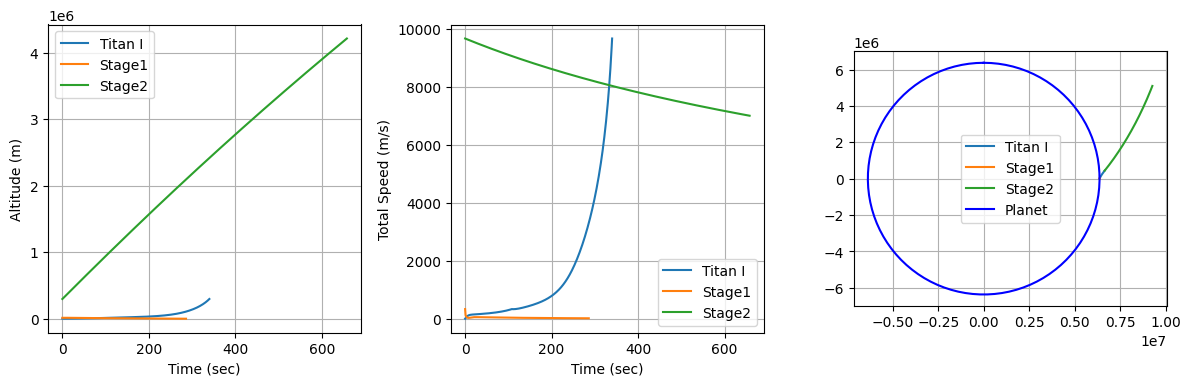

In [94]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

for obj, result in results.items():

    ax[0].plot(result["altitude"], label=obj)
    ax[1].plot(result["velocity"], label=obj)
    ax[2].plot(result["posx"], result["posz"], label=obj)

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (m)")
ax[0].grid()
ax[0].legend()

theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "b-", label="Planet")
ax[2].set_aspect("equal")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)